- ### 【articles】
- **articles shape: (105542, 25)**  

| カラム名 | 説明 |
|----------|------|
| `article_id` | 各アイテムに固有のID（10桁）。画像や他のデータと紐づけるための主キー。 |
| `product_code` | 製品コード。色違いやサイズ違いでも同じ製品には同じコードが付けられることがある。 |
| `prod_name` | 製品名（例："Short Dress"）。人間が読む商品名。 |
| `product_type_no` | 製品タイプの数値ID。 |
| `product_type_name` | 製品タイプの名称（例："Dress"、"Trousers" など）。 |
| `product_group_name` | 製品をより大きなグループに分類したもの（例："Garment Upper body"）。 |
| `graphical_appearance_no` | 見た目のパターン（デザインやプリント）の数値ID。 |
| `graphical_appearance_name` | 見た目のパターン名（例："Solid", "Striped", "All over pattern"）。 |
| `colour_group_code` | 色グループの数値コード。 |
| `colour_group_name` | 色グループ名（例："Black", "White", "Beige"）。 |
| `perceived_colour_value_id` | 明るさのレベルを示す数値ID。 |
| `perceived_colour_value_name` | 明るさの名前（例："Light", "Dark", "Medium"）。 |
| `perceived_colour_master_id` | 主観的な色グループの数値ID。 |
| `perceived_colour_master_name` | 主観的な色グループ名（例："Red", "Blue", "Beige" など）。 |
| `department_no` | デパートメント（部門）の数値ID。 |
| `department_name` | デパートメントの名称（例："Children Accessories", "Ladies Wear" など）。 |
| `index_code` | H&M内部のマーケティング・セグメントコード。 |
| `index_name` | マーケティング・セグメントの名称（例："Young", "Ladieswear" など）。 |
| `index_group_no` | indexグループの数値コード。 |
| `index_group_name` | indexグループの名前（例："Kidswear", "Ladieswear", "Menswear"）。 |
| `section_no` | セクションの数値コード。 |
| `section_name` | セクション名（例："Womens Nightwear", "Mens Shirts" など）。 |
| `garment_group_no` | 衣服グループの数値ID。 |
| `garment_group_name` | 衣服グループの名称（例："Jersey Basic", "Knitwear" など）。 |
| `detail_desc` | 製品の詳細な説明（自然言語テキスト）。モデルによっては特徴量として利用可能。 |

---

#### 🔍 分析・モデル化の観点からの補足
- **カテゴリ変数（エンコード対象）**:  
  `(prod_name)`, `product_type_name`, `product_group_name`, `graphical_appearance_name`,  
  `colour_group_name`, `index_name`, `department_name` など

- **テキスト特徴量（NLP対象）**:  
  `prod_name`, `detail_desc`

- **テキスト特徴量（テキスト違いの調査対象）**:  
  `prod_name`, ``, ``

---  

- ### 【customers】
- **customers shape:  (1371980, 7)**

| カラム名 | 説明 |
|----------|------|
| `customer_id` | 各顧客に固有の識別子（匿名化済みの16進文字列）。`transactions.csv` と結びつけて使う。 |
| `FN` | 欠損のあるバイナリフラグ（目的不明）。`1` なら何らかの属性あり、`NaN` なら無しと推定される。使わないことも多い。 |
| `Active` | 顧客がアクティブかどうかのフラグ（`1` または `NaN`）。`1` はアクティブな会員とされる。 |
| `club_member_status` | 会員ステータス（例：`ACTIVE`, `PRE-CREATE`, `LEFT CLUB` など）。顧客のエンゲージメントレベルを示す。 |
| `fashion_news_frequency` | ファッションニュース（メールなど）をどれくらいの頻度で受け取っているか（例：`NONE`, `REGULARLY`, `MONTHLY` など）。 |
| `age` | 顧客の年齢。異常値も含まれるため、前処理（分布チェック・クリッピング・標準化など）が必要。 |
| `postal_code` | 顧客の居住地域を示す郵便番号（匿名化済み）。地域性に関する分析やクラスタリングの特徴量に使われる。 |

---

#### 🔍 分析・モデル設計視点の補足

- `club_member_status`, `fashion_news_frequency` はカテゴリ変数としてエンコード対象。
- `age` は数値変数だが、分布が歪んでいるため前処理（例：クリップ、標準化、ビン分割など）推奨。
- `postal_code` はそのままでは使いにくいため、頻度ベースのエンコーディングやクラスタリングが有効。
- `FN`, `Active` は意味が不明なため注意が必要（`NaN` を `0` 扱いにしてバイナリ変数化するのが一般的）。

---

- **【transactions_train】**
- **transactions_train shape: (31788324, 5)**

| カラム名 | 説明 |
|----------|------|
| `t_dat` | 購入日時（`YYYY-MM-DD` 形式の日付）。トランザクションが発生した日付。 |
| `customer_id` | 顧客の識別子（匿名化された16進文字列）。`customers.csv` や提出用推薦と紐づける主キー。 |
| `article_id` | 購入された商品のID（10桁）。`articles.csv` に対応し、商品属性と紐づけ可能。 |
| `price` | 購入時の価格（単価、税込、float型）。同じ商品でも購入時期により変動あり。 |
| `sales_channel_id` | 購入チャネルの区分：`1` = オンライン、`2` = 実店舗（公式未公開だが、一般的な解釈）。 |

---

#### 🔍 分析・前処理におけるポイント

- `t_dat` をもとに、以下のような**時系列特徴量**を作成可能：
  - 直近〇日間の購入数、頻度
  - 曜日・月の傾向（例：週末に多い/少ない）
  - 最終購入日からの経過日数（リピート分析）

- `price` は商品ごとに変動があるため、価格変動の傾向やセールの影響を捉える特徴量を構築可能。

- `sales_channel_id` によって、チャネルごとの行動傾向の違いを分析・モデリングに活用できる。


In [2]:
import pandas as pd, numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier

import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)

print("ok")

ok


In [ ]:
# -------------------------
# 1. データ読み込み
# -------------------------
transactions = pd.read_csv("/Users/kurokawa/Desktop/kaggle/H&M/transactions_train.csv")
customers = pd.read_csv("/Users/kurokawa/Desktop/kaggle/H&M/customers.csv")
articles = pd.read_csv("/Users/kurokawa/Desktop/kaggle/H&M/articles.csv")

print("transactions shape: ", transactions.shape)
print("customers shape: ", customers.shape)
print("articles shape: ", articles.shape)

articles.head()

transactions shape:  (31788324, 5)
customers shape:  (1371980, 7)
articles shape:  (105542, 25)


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,4,Dark,5,Black,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,3,Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,1,Dusty Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,4,Dark,5,Black,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulded, lightly padded cups that shape the bust and pro..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,3,Light,9,White,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulded, lightly padded cups that shape the bust and pro..."


In [8]:
# 正例データの抽出
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
positive = transactions[transactions['t_dat'] >= '2020-09-15']

# 顧客・商品のユニーク値を NumPy 配列に変換
customers_sample = positive['customer_id'].unique()
articles_sample = positive['article_id'].unique()

# ランダムな負例の生成（正例の3倍）
np.random.seed(42)
negative_samples = pd.DataFrame({
    'customer_id': np.random.choice(customers_sample, size=positive.shape[0]*3),
    'article_id': np.random.choice(articles_sample, size=positive.shape[0]*3),
})

# 正例の組（customer_id, article_id）を set に変換
positive_pairs = set(zip(
    positive['customer_id'],
    positive['article_id']
))

# 正例と重複していない組だけを負例とする
negative_samples = negative_samples[~negative_samples.apply(tuple, axis=1).isin(positive_pairs)]

# ラベル付け
positive_labeled = positive[['customer_id', 'article_id']].copy()
positive_labeled['target'] = 1
negative_labeled = negative_samples.copy()
negative_labeled['target'] = 0
data = pd.concat([positive_labeled, negative_labeled], ignore_index=True)

# ダウンサンプリング（正例:負例 = 1:1）
n_pos = len(positive_labeled)
data = pd.concat([
    positive_labeled,
    negative_labeled.sample(n=n_pos, random_state=42)
], ignore_index=True)

# 結合（articles, customers は pandas DataFrame）
data = data.merge(articles, on='article_id', how='left')
data = data.merge(customers, on='customer_id', how='left')

# 特徴量・目的変数に分割
drop_cols = ['customer_id', 'article_id']
X = data.drop(columns=drop_cols + ['target'])
y = data['target']

print("ok")


ok


In [9]:
# 7. ラベルエンコーディング
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype("category")
print("Xのカラム数: ", len(X.columns))
print("Xのカラム一覧: ", X.columns)

# 数値型カラムの一覧を取得
numeric_cols = X.select_dtypes(include=["number"]).columns
# 数とカラム名を表示
print(f"数値カラムの数: {len(numeric_cols)}")
print("数値カラムの一覧:")
print(numeric_cols.tolist())

# カテゴリ型カラムの一覧を取得
category_cols = X.select_dtypes(include=["category"]).columns
# 数とカラム名を表示
print(f"カテゴリカラムの数: {len(category_cols)}")
print("カテゴリカラムの一覧:")
print(category_cols.tolist())

# 8. train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 9. モデル学習
model = LGBMClassifier(random_state=42)
model.fit(X_train, y_train)

# 10. スコア予測
data['pred_score'] = model.predict_proba(X)[:, 1]

# 11. MAP@12 評価
def apk(actual, predicted, k=12):
    if len(predicted) > k:
        predicted = predicted[:k]
    score = 0.0
    num_hits = 0.0
    for i, p in enumerate(predicted):
        if p in actual and p not in predicted[:i]:
            num_hits += 1.0
            score += num_hits / (i + 1.0)
    return score / min(len(actual), k) if actual else 0.0

top12 = (
    data
    .groupby('customer_id', group_keys=False) # pandasの挙動上, group_keysを追加
    .apply(lambda df: df.sort_values('pred_score', ascending=False).head(12))
    .reset_index(drop=True)
)

map_scores = []
for cid, group in top12.groupby('customer_id'):
    actual = set(group[group['target'] == 1]['article_id'])
    predicted = group['article_id'].tolist()
    map_scores.append(apk(actual, predicted, k=12))

print(f"MAP@12: {np.mean(map_scores):.5f}")

Xのカラム数:  30
Xのカラム一覧:  Index(['product_code', 'prod_name', 'product_type_no', 'product_type_name',
       'product_group_name', 'graphical_appearance_no',
       'graphical_appearance_name', 'colour_group_code', 'colour_group_name',
       'perceived_colour_value_id', 'perceived_colour_value_name',
       'perceived_colour_master_id', 'perceived_colour_master_name',
       'department_no', 'department_name', 'index_code', 'index_name',
       'index_group_no', 'index_group_name', 'section_no', 'section_name',
       'garment_group_no', 'garment_group_name', 'detail_desc', 'FN', 'Active',
       'club_member_status', 'fashion_news_frequency', 'age', 'postal_code'],
      dtype='object')
数値カラムの数: 13
数値カラムの一覧:
['product_code', 'product_type_no', 'graphical_appearance_no', 'colour_group_code', 'perceived_colour_value_id', 'perceived_colour_master_id', 'department_no', 'index_group_no', 'section_no', 'garment_group_no', 'FN', 'Active', 'age']
カテゴリカラムの数: 17
カテゴリカラムの一覧:
['prod_name', 'product_

In [10]:
print(len(data.columns))
data.columns

34


Index(['customer_id', 'article_id', 'target', 'product_code', 'prod_name',
       'product_type_no', 'product_type_name', 'product_group_name',
       'graphical_appearance_no', 'graphical_appearance_name',
       'colour_group_code', 'colour_group_name', 'perceived_colour_value_id',
       'perceived_colour_value_name', 'perceived_colour_master_id',
       'perceived_colour_master_name', 'department_no', 'department_name',
       'index_code', 'index_name', 'index_group_no', 'index_group_name',
       'section_no', 'section_name', 'garment_group_no', 'garment_group_name',
       'detail_desc', 'FN', 'Active', 'club_member_status',
       'fashion_news_frequency', 'age', 'postal_code', 'pred_score'],
      dtype='object')

In [14]:
# sample_submission の読み込み
sample_submission = pd.read_csv("/Users/kurokawa/Desktop/kaggle/H&M/sample_submission.csv")

# 人気商品（多めに20個）→ 10桁ゼロ埋め
popular_articles = [
    str(a).zfill(10) for a in positive['article_id'].value_counts().head(20).index
]

# 12個に満たないときに補完する関数（ゼロ埋め込み）
def recommend_12_articles(article_list):
    article_list = [str(a).zfill(10) for a in article_list]  # ✅ ゼロ埋め
    if len(article_list) >= 12:
        return article_list[:12]
    else:
        needed = 12 - len(article_list)
        fill_items = [a for a in popular_articles if a not in article_list][:needed]
        return article_list + fill_items

# 顧客ごとの推薦（12個保証）
submission_pred = (
    top12.groupby('customer_id')['article_id']
    .apply(lambda x: ' '.join(recommend_12_articles(x)))
    .reset_index()
)

# sample_submissionにマージ（形式維持）
submission = sample_submission[['customer_id']].merge(submission_pred, on='customer_id', how='left')

# 欠損のある顧客には人気商品12個を推薦
popular_12 = ' '.join(popular_articles[:12])
submission['prediction'] = submission['article_id'].fillna(popular_12)
submission.drop(columns='article_id', inplace=True)

# 保存（UTF-8）
submission.to_csv("submission.csv", index=False, encoding="utf-8")
print("✅ 10桁ゼロ埋め済み、欠損補完済み submission.csv を保存しました")

✅ 10桁ゼロ埋め済み、欠損補完済み submission.csv を保存しました


In [15]:
pd.set_option("display.max_colwidth", None)

print("sample_submission shape: ", sample_submission.shape)
print("submission shape: ", submission.shape)
submission.head(20)

sample_submission shape:  (1371980, 2)
submission shape:  (1371980, 2)


,customer_id,prediction
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d25f88aa139fdfc657,0924243001 0924243002 0923758001 0918522001 0909370001 0866731001 0751471001 0915529003 0915529005 0448509014 0762846027 0714790020
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa,0924243001 0924243002 0923758001 0918522001 0909370001 0866731001 0751471001 0915529003 0915529005 0448509014 0762846027 0714790020
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318,0456163090 0794321007 0762173013 0781180002 0924243001 0924243002 0923758001 0918522001 0909370001 0866731001 0751471001 0915529003
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2c5feb1ca5dff07c43e,0924243001 0924243002 0923758001 0918522001 0909370001 0866731001 0751471001 0915529003 0915529005 0448509014 0762846027 0714790020
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801fe7fc0f26dd8d65a85a,0924243001 0924243002 0923758001 0918522001 0909370001 0866731001 0751471001 0915529003 0915529005 0448509014 0762846027 0714790020
5,000064249685c11552da43ef22a5030f35a147f723d5b02ddd9fd22452b1f5a6,0924243001 0924243002 0923758001 0918522001 0909370001 0866731001 0751471001 0915529003 0915529005 0448509014 0762846027 0714790020
6,0000757967448a6cb83efb3ea7a3fb9d418ac7adf2379d8cd0c725276a467a2a,0924243001 0924243002 0923758001 0918522001 0909370001 0866731001 0751471001 0915529003 0915529005 0448509014 0762846027 0714790020
7,00007d2de826758b65a93dd24ce629ed66842531df6699338c5570910a014cc2,0924243001 0924243002 0923758001 0918522001 0909370001 0866731001 0751471001 0915529003 0915529005 0448509014 0762846027 0714790020
8,00007e8d4e54114b5b2a9b51586325a8d0fa74ea23ef77334eaec4ffccd7ebcc,0924243001 0924243002 0923758001 0918522001 0909370001 0866731001 0751471001 0915529003 0915529005 0448509014 0762846027 0714790020
9,00008469a21b50b3d147c97135e25b4201a8c58997f78782a0cc706645e14493,0924243001 0924243002 0923758001 0918522001 0909370001 0866731001 0751471001 0915529003 0915529005 0448509014 0762846027 0714790020


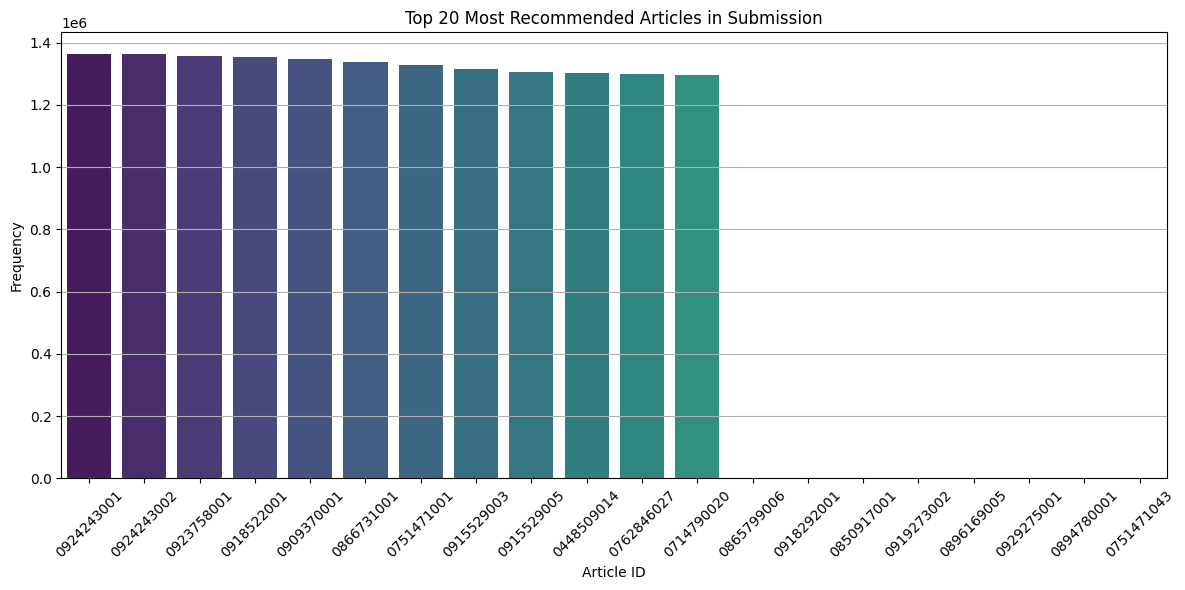

In [19]:
# 上位20個の商品の可視化

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ========== ① 全顧客の prediction（スペース区切り文字列）を article_id リストに展開 ==========
# prediction カラム（"1234567890 0987654321 ..."）を分割して1つのリストに
all_article_ids = submission['prediction'].str.split().explode()

# ========== ② 出現回数をカウント（人気順） ==========
article_counts = Counter(all_article_ids)
top_articles = all_article_ids.value_counts().head(20)  # 上位20個に制限

# ========== ③ 可視化 ==========
articles, counts = zip(*top_articles.items())

plt.figure(figsize=(12, 6))
sns.barplot(x=list(articles), y=list(counts), palette="viridis")
plt.title("Top 20 Most Recommended Articles in Submission")
plt.xlabel("Article ID")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

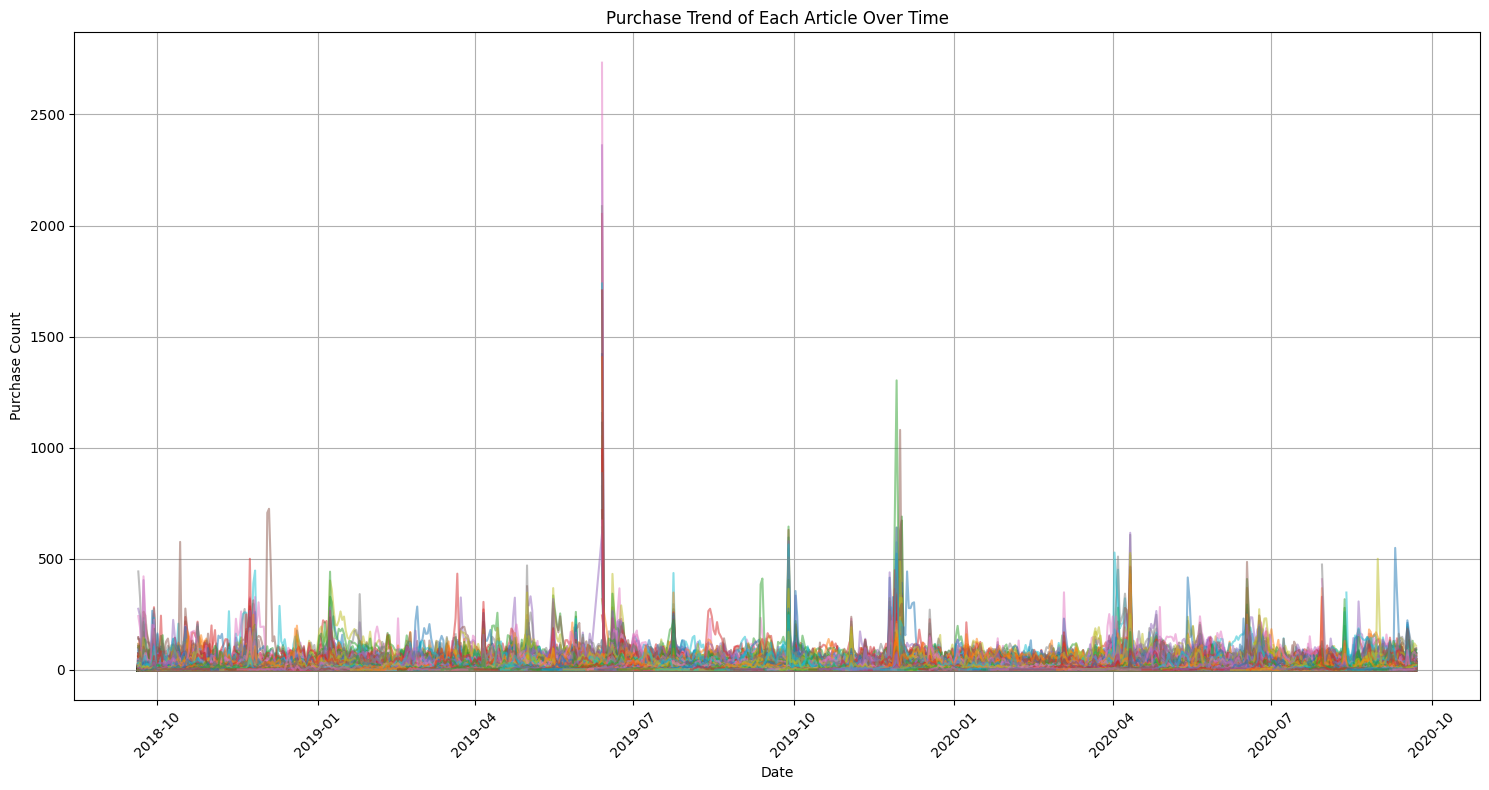

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 前処理：日付を datetime 型に変換（すでにやってる場合は不要）
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# 日付×article_idごとの購入回数を集計
article_daily = transactions.groupby(['t_dat', 'article_id']).size().reset_index(name='count')

# 可視化
plt.figure(figsize=(15, 8))

# 全article_idごとに折れ線グラフを描画
for article_id, group in article_daily.groupby('article_id'):
    plt.plot(group['t_dat'], group['count'], label=article_id, alpha=0.5)

plt.title("Purchase Trend of Each Article Over Time")
plt.xlabel("Date")
plt.ylabel("Purchase Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


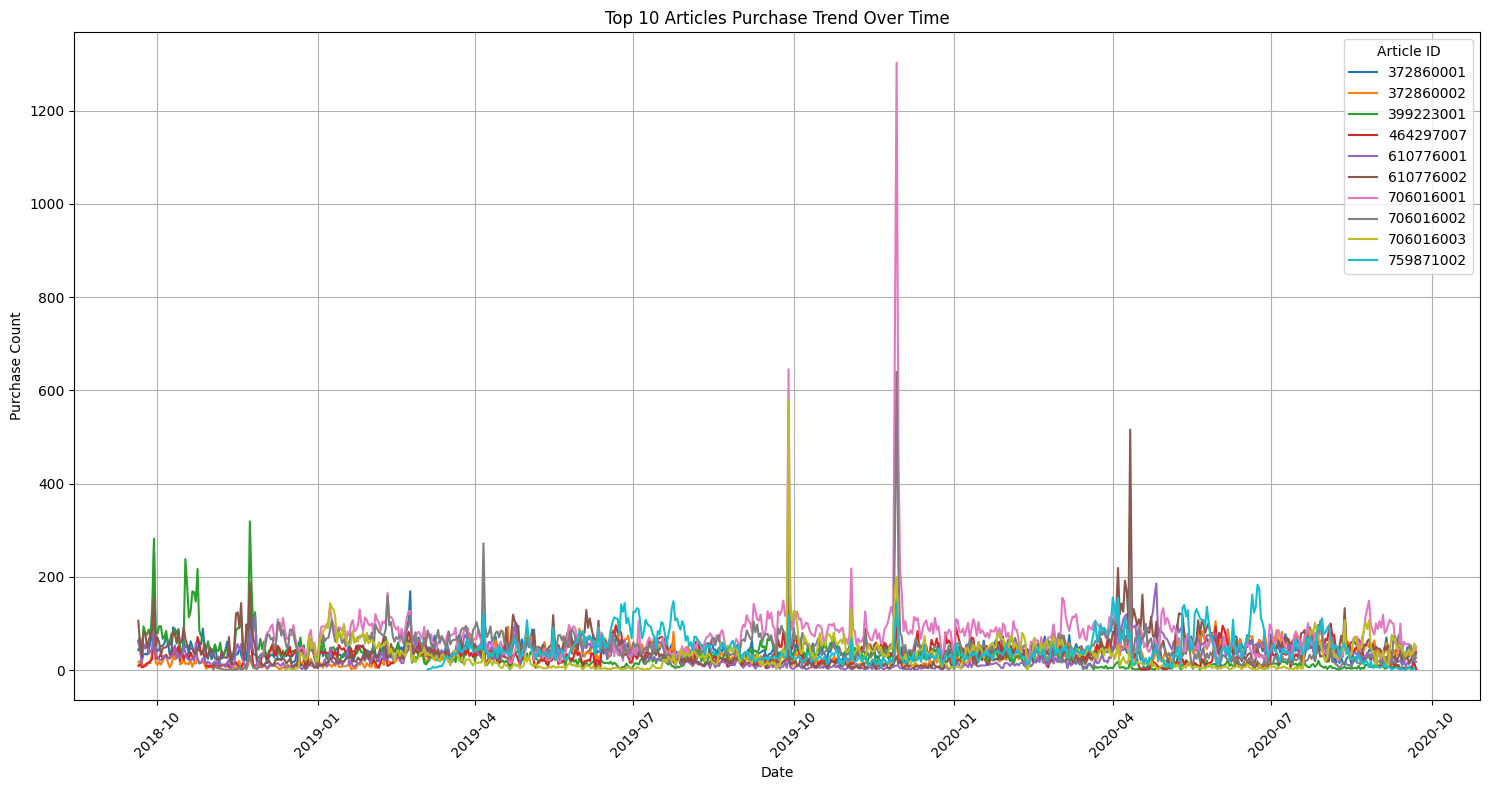

In [21]:
# 人気の上位10商品を抽出
top_articles = transactions['article_id'].value_counts().head(10).index

# 該当データだけ抽出
filtered = article_daily[article_daily['article_id'].isin(top_articles)]

# 可視化
plt.figure(figsize=(15, 8))
for article_id, group in filtered.groupby('article_id'):
    plt.plot(group['t_dat'], group['count'], label=str(article_id))
    
plt.title("Top 10 Articles Purchase Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Purchase Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title="Article ID")
plt.tight_layout()
plt.show()


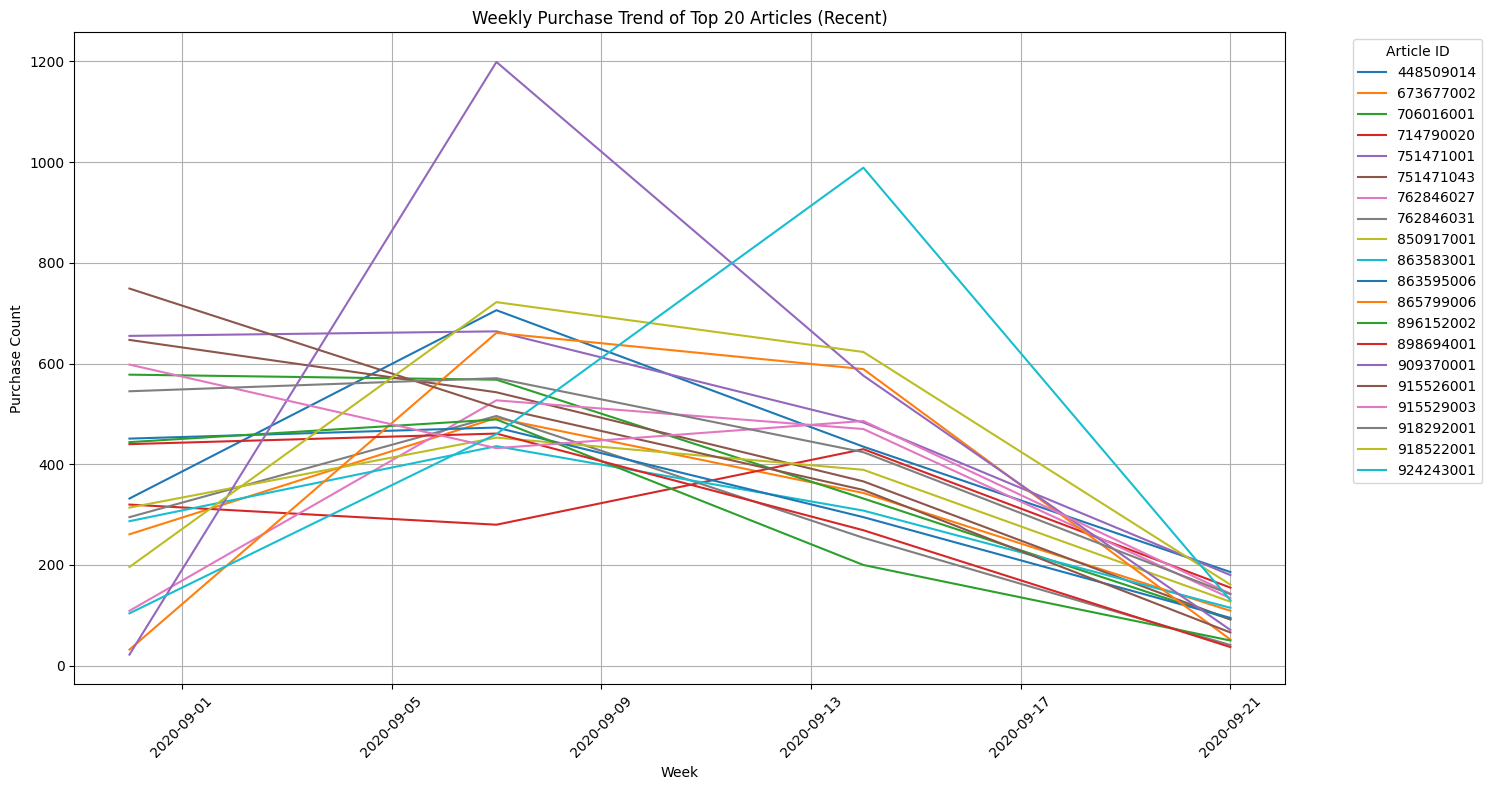

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 日付をdatetimeに変換
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# ==== ① 直近の期間でフィルター（例：2020年9月1日以降）====
recent = transactions[transactions['t_dat'] >= '2020-09-01']

# ==== ② 上位20商品の article_id を取得 ====
top_articles = recent['article_id'].value_counts().head(20).index

# ==== ③ 対象記事のデータだけ抽出 ====
filtered = recent[recent['article_id'].isin(top_articles)]

# ==== ④ 週単位に変換して集計 ====
filtered['week'] = filtered['t_dat'].dt.to_period('W').dt.start_time
article_weekly = (
    filtered.groupby(['week', 'article_id'])
    .size()
    .reset_index(name='count')
)

# ==== ⑤ 可視化 ====
plt.figure(figsize=(15, 8))
for article_id, group in article_weekly.groupby('article_id'):
    plt.plot(group['week'], group['count'], label=str(article_id))

plt.title("Weekly Purchase Trend of Top 20 Articles (Recent)")
plt.xlabel("Week")
plt.ylabel("Purchase Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title="Article ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


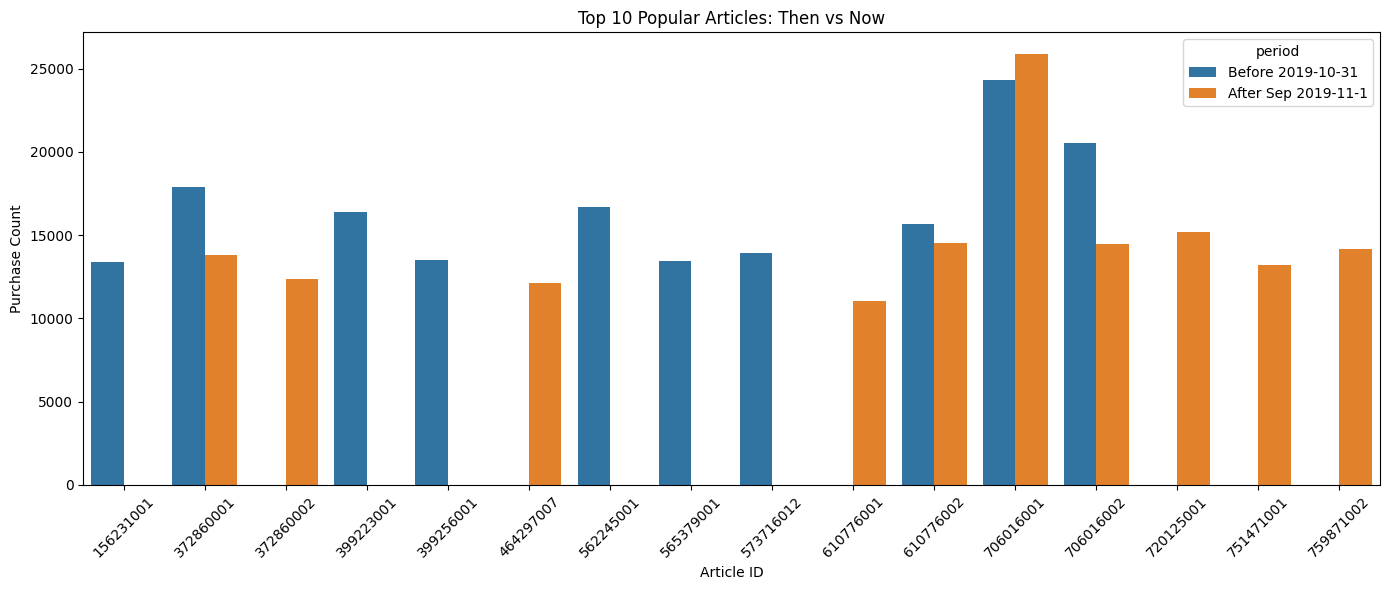

In [ ]:
# 1年間ずつで分離させる

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 日付型に変換
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# ==== ① 期間を2つ定義 ====
old_period = transactions[transactions['t_dat'] < '2019-10-31']
recent_period = transactions[transactions['t_dat'] >= '2019-11-01']

# ==== ② 各期間で人気上位10商品を取得 ====
old_top = old_period['article_id'].value_counts().head(10)
recent_top = recent_period['article_id'].value_counts().head(10)

# ==== ③ 共通のデータ構造にまとめる ====
df_old = old_top.reset_index()
df_old.columns = ['article_id', 'count']
df_old['period'] = 'Before 2019-10-31'

df_recent = recent_top.reset_index()
df_recent.columns = ['article_id', 'count']
df_recent['period'] = 'After Sep 2019-11-1'

# ==== ④ 結合 ====
combined = pd.concat([df_old, df_recent], ignore_index=True)

# ==== ⑤ 可視化 ====
plt.figure(figsize=(14, 6))
sns.barplot(data=combined, x='article_id', y='count', hue='period')
plt.title("Top 10 Popular Articles: Then vs Now")
plt.xlabel("Article ID")
plt.ylabel("Purchase Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


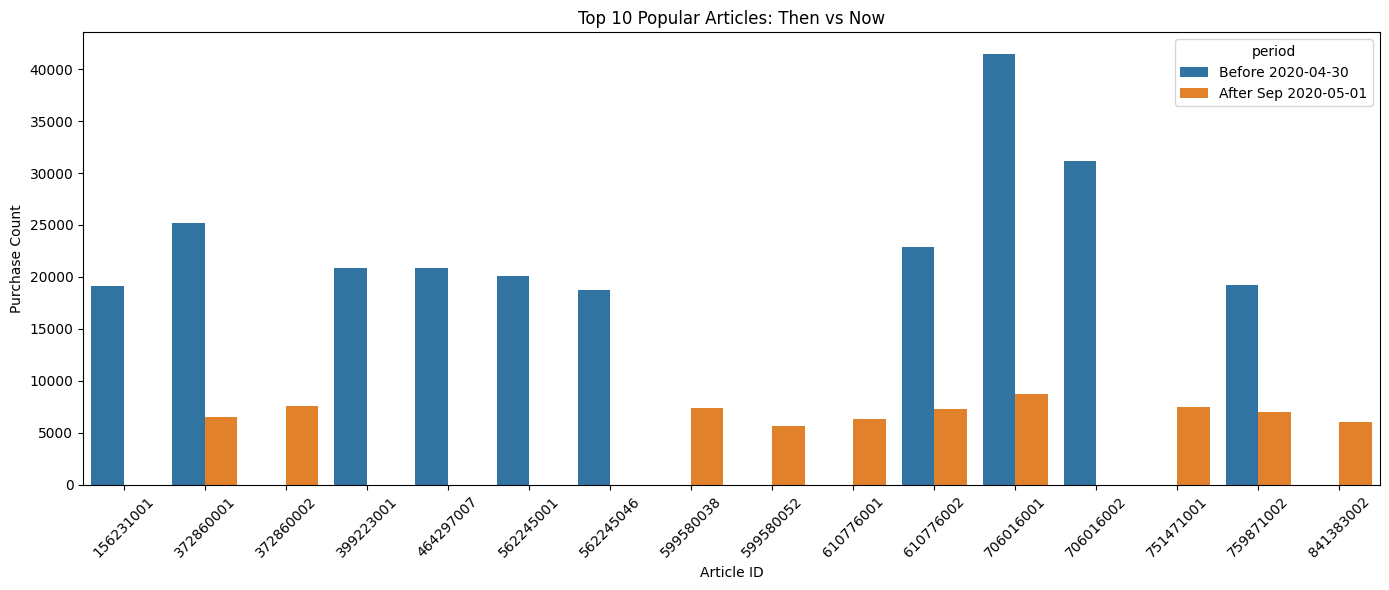

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 日付型に変換
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# ==== ① 期間を2つ定義 ====
old_period = transactions[transactions['t_dat'] < '2020-04-30']
recent_period = transactions[transactions['t_dat'] >= '2020-05-01']

# ==== ② 各期間で人気上位10商品を取得 ====
old_top = old_period['article_id'].value_counts().head(10)
recent_top = recent_period['article_id'].value_counts().head(10)

# ==== ③ 共通のデータ構造にまとめる ====
df_old = old_top.reset_index()
df_old.columns = ['article_id', 'count']
df_old['period'] = 'Before 2020-04-30'

df_recent = recent_top.reset_index()
df_recent.columns = ['article_id', 'count']
df_recent['period'] = 'After Sep 2020-05-01'

# ==== ④ 結合 ====
combined = pd.concat([df_old, df_recent], ignore_index=True)

# ==== ⑤ 可視化 ====
plt.figure(figsize=(14, 6))
sns.barplot(data=combined, x='article_id', y='count', hue='period')
plt.title("Top 10 Popular Articles: Then vs Now")
plt.xlabel("Article ID")
plt.ylabel("Purchase Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier

# -------------------------
# 1. データ読み込み & サンプリング
# -------------------------
transactions = pd.read_csv("/Users/kurokawa/Desktop/kaggle/H&M/transactions_train.csv")
customers = pd.read_csv("/Users/kurokawa/Desktop/kaggle/H&M/customers.csv")
articles = pd.read_csv("/Users/kurokawa/Desktop/kaggle/H&M/articles.csv")

print("transactions shape: ", transactions.shape)
print("customers shape: ", customers.shape)
print("articles shape: ", articles.shape)

# データのコピー
articles_copy = articles.copy()
customers_copy = customers.copy()
transactions_copy = transactions.copy()

# 日付変換
transactions_copy['t_dat'] = pd.to_datetime(transactions_copy['t_dat'])

# 正例抽出（2020-09-15以降の取引）
positive = transactions_copy[transactions_copy['t_dat'] >= '2020-09-15']

# 顧客・商品を numpy 配列で抽出
customers_sample = positive['customer_id'].unique()
articles_sample = positive['article_id'].unique()

# ランダムな負例を生成（正例の3倍）
np.random.seed(42)
negative_samples = pd.DataFrame({
    'customer_id': np.random.choice(customers_sample, size=positive.shape[0]*3),
    'article_id': np.random.choice(articles_sample, size=positive.shape[0]*3),
})

# 正例ペア集合を作成
positive_pairs = set(zip(positive['customer_id'], positive['article_id']))

# 正例と重複しない負例だけを抽出
negative_samples = negative_samples[~negative_samples.apply(tuple, axis=1).isin(positive_pairs)]

# 正例・負例にラベルを付加
positive_labeled = positive[['customer_id', 'article_id']].copy()
positive_labeled['target'] = 1
negative_labeled = negative_samples.copy()
negative_labeled['target'] = 0

# 正例：負例 = 1:1 にダウンサンプリング
n_pos = len(positive_labeled)
negative_labeled = negative_labeled.sample(n=n_pos, random_state=42)
data = pd.concat([positive_labeled, negative_labeled], ignore_index=True)

# データ結合（特徴量追加）
data = data.merge(articles_copy, on='article_id', how='left')
data = data.merge(customers_copy, on='customer_id', how='left')

# 特徴量・目的変数に分割
drop_cols = ['customer_id', 'article_id']
X = data.drop(columns=drop_cols + ['target'])
y = data['target']

print("ok")

# カテゴリ型に変換（ラベルエンコーディング回避）
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype("category")

print("Xのカラム数:", len(X.columns))
print("Xのカラム一覧:", X.columns.tolist())

# 数値カラム
numeric_cols = X.select_dtypes(include="number").columns
print("数値カラム数:", len(numeric_cols))
print("数値カラム一覧:", numeric_cols.tolist())

# カテゴリカラム
category_cols = X.select_dtypes(include="category").columns
print("カテゴリカラム数:", len(category_cols))
print("カテゴリカラム一覧:", category_cols.tolist())

# train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# モデル学習
model = LGBMClassifier(random_state=42)
model.fit(X_train, y_train)

# 全体データに対するスコア算出
data['pred_score'] = model.predict_proba(X)[:, 1]

# MAP@12 評価関数
def apk(actual, predicted, k=12):
    if len(predicted) > k:
        predicted = predicted[:k]
    score = 0.0
    num_hits = 0.0
    for i, p in enumerate(predicted):
        if p in actual and p not in predicted[:i]:
            num_hits += 1.0
            score += num_hits / (i + 1.0)
    return score / min(len(actual), k) if actual else 0.0

# 顧客ごとに top12 を抽出
top12 = (
    data
    .groupby('customer_id', group_keys=False)
    .apply(lambda df: df.sort_values('pred_score', ascending=False).head(12))
    .reset_index(drop=True)
)

# MAPスコア計算
map_scores = []
for cid, group in top12.groupby('customer_id'):
    actual = set(group[group['target'] == 1]['article_id'])
    predicted = group['article_id'].tolist()
    map_scores.append(apk(actual, predicted, k=12))

print(f"MAP@12: {np.mean(map_scores):.5f}")


transactions shape:  (31788324, 5)
customers shape:  (1371980, 7)
articles shape:  (105542, 25)
ok
Xのカラム数: 30
Xのカラム一覧: ['product_code', 'prod_name', 'product_type_no', 'product_type_name', 'product_group_name', 'graphical_appearance_no', 'graphical_appearance_name', 'colour_group_code', 'colour_group_name', 'perceived_colour_value_id', 'perceived_colour_value_name', 'perceived_colour_master_id', 'perceived_colour_master_name', 'department_no', 'department_name', 'index_code', 'index_name', 'index_group_no', 'index_group_name', 'section_no', 'section_name', 'garment_group_no', 'garment_group_name', 'detail_desc', 'FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'age', 'postal_code']
数値カラム数: 13
数値カラム一覧: ['product_code', 'product_type_no', 'graphical_appearance_no', 'colour_group_code', 'perceived_colour_value_id', 'perceived_colour_master_id', 'department_no', 'index_group_no', 'section_no', 'garment_group_no', 'FN', 'Active', 'age']
カテゴリカラム数: 17
カテゴリカラム一覧: ['prod_name', '

In [35]:
import pandas as pd
import numpy as np

# ========== ① 最新度 × 購入頻度 スコアで記事をランキング ==========

# transactions データ読み込み（例: 適切に指定）
transactions = transactions[["t_dat", "article_id"]].copy()

# 🔧 日付型に変換
transactions["t_dat"] = pd.to_datetime(transactions["t_dat"])

# 最新日付を取得
last_date = transactions["t_dat"].max()

# 🔧 日数差分（古いほど値が大きい）※0日だったら1日に丸める
transactions["days_ago"] = (last_date - transactions["t_dat"]).dt.days.clip(lower=1)

# スコア = 頻度 / log(1 + 経過日数)
transactions["recency_weight"] = 1 / np.log1p(transactions["days_ago"])
recency_score = transactions.groupby("article_id")["recency_weight"].sum()

# 🔧 スコア上位20個を抽出してゼロ埋め（pandas 用に修正）
popular_articles = [
    str(a).zfill(10) for a in recency_score.sort_values(ascending=False).head(20).index.tolist()
]

# ========== ② 関数：12個未満の推薦を補完 ==========

def recommend_12_articles(article_list):
    article_list = [str(a).zfill(10) for a in article_list]
    if len(article_list) >= 12:
        return article_list[:12]
    else:
        needed = 12 - len(article_list)
        fill_items = [a for a in popular_articles if a not in article_list][:needed]
        return article_list + fill_items

# ========== ③ 顧客ごとの推薦リストを構築 ==========

submission_pred = (
    top12.groupby('customer_id')['article_id']
    .apply(lambda x: ' '.join(recommend_12_articles(x)))
    .reset_index()
)

# ========== ④ sample_submission に統合 ==========

sample_submission = pd.read_csv("/Users/kurokawa/Desktop/kaggle/H&M/sample_submission.csv")
submission = sample_submission[['customer_id']].merge(submission_pred, on='customer_id', how='left')

# 欠損補完：推薦データが無い顧客には人気商品を12個補完
popular_12 = ' '.join(popular_articles[:12])
submission['prediction'] = submission['article_id'].fillna(popular_12)
submission.drop(columns='article_id', inplace=True)

# ========== ⑤ CSV出力 ==========

submission.to_csv("submission.csv", index=False, encoding="utf-8")
print("✅ 最新度×頻度で補完された submission.csv を保存しました")

✅ 最新度×頻度で補完された submission.csv を保存しました


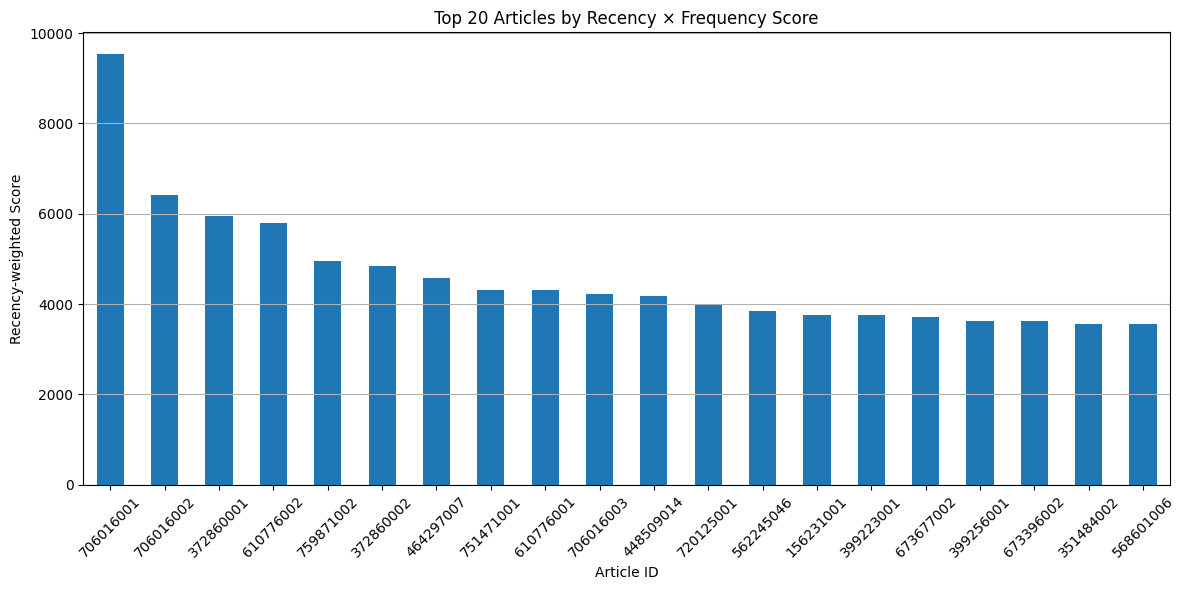

In [37]:
import matplotlib.pyplot as plt

# スコアを降順にソートして上位20件を抽出（→ Pandas Series に変換）
top_recency_score = recency_score.sort_values(ascending=False).head(20)

# 棒グラフで可視化
plt.figure(figsize=(12, 6))
top_recency_score.plot(kind='bar')
plt.title("Top 20 Articles by Recency × Frequency Score")
plt.xlabel("Article ID")
plt.ylabel("Recency-weighted Score")
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [46]:
# ① recency_score 上位20件（index が article_id）
top_recency_score = recency_score.sort_values(ascending=False).head(20)
print("Recency 上位20の article_id:", top_recency_score.index.tolist())

# ② all_article_ids の出現回数上位20（index が article_id）
top_articles = all_article_ids.value_counts().head(20)
print("人気記事 上位20の article_id:", top_articles.index.tolist())

# ③ 共通している article_id を抽出
common_articles = set(top_recency_score.index) & set(top_articles.index)
print("共通している article_id:", list(common_articles))


Recency 上位20の article_id: [706016001, 706016002, 372860001, 610776002, 759871002, 372860002, 464297007, 751471001, 610776001, 706016003, 448509014, 720125001, 562245046, 156231001, 399223001, 673677002, 399256001, 673396002, 351484002, 568601006]
人気記事 上位20の article_id: ['0924243001', '0924243002', '0923758001', '0918522001', '0909370001', '0866731001', '0751471001', '0915529003', '0915529005', '0448509014', '0762846027', '0714790020', '0865799006', '0918292001', '0850917001', '0919273002', '0896169005', '0929275001', '0894780001', '0751471043']
共通している article_id: []


In [47]:
df_common = pd.DataFrame({
    "recency_score": top_recency_score.loc[list(common_articles)],
    "popularity_count": top_articles.loc[list(common_articles)]
}).sort_values("recency_score", ascending=False)

print(df_common)


Empty DataFrame
Columns: [recency_score, popularity_count]
Index: []


In [48]:
# どんなジャンルの商品が人気なのか？

# 上位20件の article_id を取得（int型も str に統一）
recency_ids = [str(a).zfill(10) for a in [706016001, 706016002, 372860001, 610776002, 759871002, 372860002, 464297007, 751471001, 610776001, 706016003, 448509014, 720125001, 562245046, 156231001, 399223001, 673677002, 399256001, 673396002, 351484002, 568601006]]
popular_ids = ['0924243001', '0924243002', '0923758001', '0918522001', '0909370001', '0866731001', '0751471001', '0915529003', '0915529005', '0448509014', '0762846027', '0714790020', '0865799006', '0918292001', '0850917001', '0919273002', '0896169005', '0929275001', '0894780001', '0751471043']

# article_id を str に統一（ゼロ埋めが必要な場合）
articles_copy["article_id"] = articles_copy["article_id"].astype(str).str.zfill(10)

# 該当商品だけ抽出
recency_articles = articles_copy[articles_copy["article_id"].isin(recency_ids)]
popular_articles = articles_copy[articles_copy["article_id"].isin(popular_ids)]

# カテゴリ別に集計
print("🔷 Recency 上位20商品のカテゴリ分布:")
print(recency_articles["product_group_name"].value_counts())
print(recency_articles["product_type_name"].value_counts())

print("\n🔶 全体人気 上位20商品のカテゴリ分布:")
print(popular_articles["product_group_name"].value_counts())
print(popular_articles["product_type_name"].value_counts())


🔷 Recency 上位20商品のカテゴリ分布:
product_group_name
Garment Lower body    9
Garment Upper body    5
Socks & Tights        3
Swimwear              1
Underwear             1
Accessories           1
Name: count, dtype: int64
product_type_name
Trousers            8
Socks               2
T-shirt             2
Underwear Tights    1
Swimwear bottom     1
Underwear bottom    1
Blazer              1
Belt                1
Sweater             1
Leggings/Tights     1
Vest top            1
Name: count, dtype: int64

🔶 全体人気 上位20商品のカテゴリ分布:
product_group_name
Garment Lower body    9
Garment Upper body    9
Garment Full body     1
Unknown               1
Name: count, dtype: int64
product_type_name
Trousers           6
Sweater            5
Leggings/Tights    3
Shirt              2
Cardigan           1
Dress              1
Blouse             1
Unknown            1
Name: count, dtype: int64


In [ ]:
# 直近と昔とで人気の商品が異なる


✅ 年齢ごとのカテゴリ別購入数（集計表）:


product_group_name,Accessories,Bags,Cosmetic,Fun,Furniture,Garment Full body,Garment Lower body,Garment Upper body,Garment and Shoe care,Interior textile,Items,Nightwear,Shoes,Socks & Tights,Stationery,Swimwear,Underwear,Underwear/nightwear,Unknown
age_group,,,,,,,,,,,,,,,,,,,
"[10, 15)",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"[15, 20)",47554,380,9,0,4,55539,140013,262301,3,0,228,4430,8964,12457,22,88253,68762,2,2481
"[20, 25)",348098,1956,102,2,62,577960,1206357,2223410,46,4,1380,52028,117515,116265,56,616400,554906,24,17078
"[25, 30)",374208,1570,148,0,147,823102,1530253,2766163,65,12,1190,75996,182971,158792,46,664194,623378,106,22597
"[30, 35)",218118,782,203,0,65,510606,946613,1655146,40,23,529,50795,120818,102032,13,346896,373310,167,13974
"[35, 40)",103995,388,246,0,35,251052,478102,804633,24,18,252,26966,62210,49926,30,134319,169434,123,6980
"[40, 45)",93903,374,289,2,45,232539,490381,798601,11,9,283,26451,50683,46999,15,125565,149891,41,6494
"[45, 50)",128155,648,233,1,75,317780,700796,1158211,25,2,518,35418,57104,64416,13,203303,209907,18,9164
"[50, 55)",136330,610,127,0,51,363507,745647,1319296,26,5,494,37166,62787,69218,9,223734,225097,15,9650


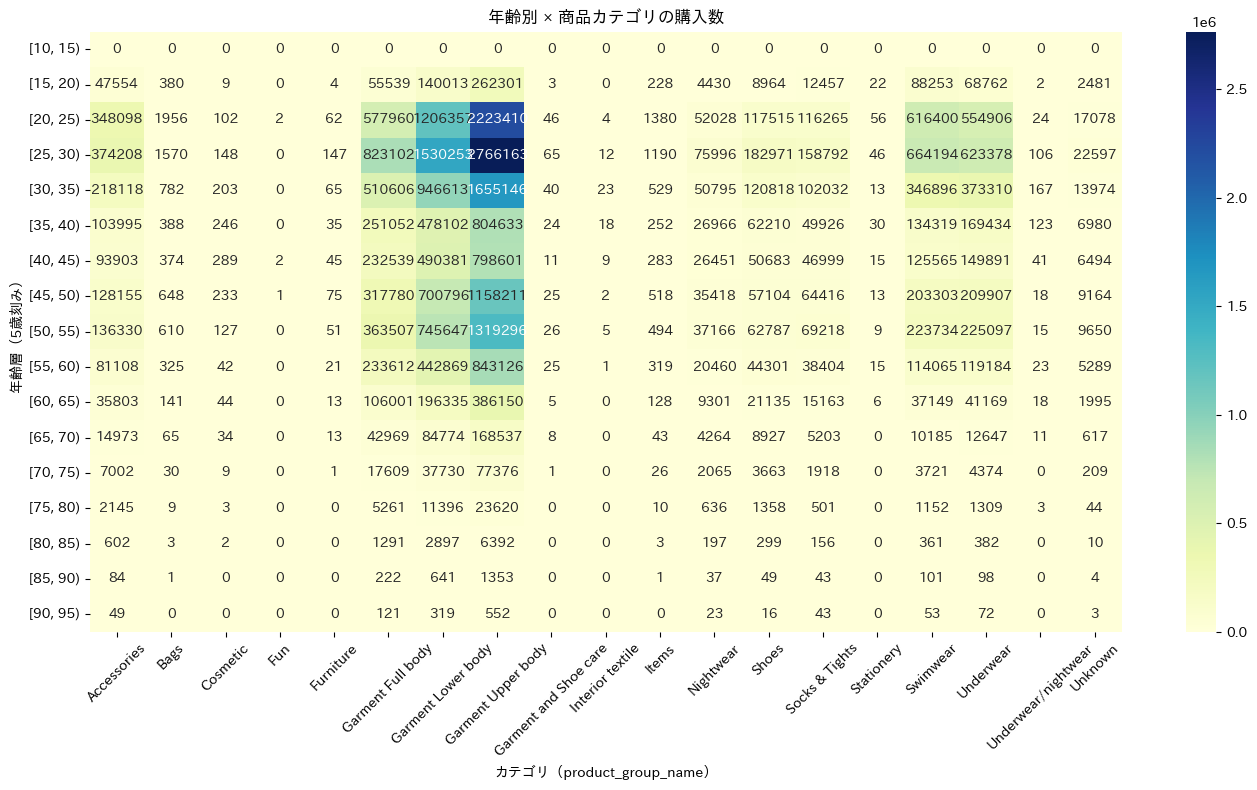

In [51]:

import japanize_matplotlib

# 1. 必要な列だけに絞ってコピー
transactions_subset = transactions_copy[["customer_id", "article_id"]].copy()
customers_subset = customers_copy[["customer_id", "age"]].copy()
articles_subset = articles_copy[["article_id", "product_group_name"]].copy()

# 🔧 article_id をすべて str に変換（ゼロ埋めがあれば統一）
transactions_subset["article_id"] = transactions_subset["article_id"].astype(str).str.zfill(10)
articles_subset["article_id"] = articles_subset["article_id"].astype(str).str.zfill(10)

# 2. 各データをマージ（顧客＋商品＋カテゴリ）
merged = transactions_subset.merge(customers_subset, on="customer_id", how="left")
merged = merged.merge(articles_subset, on="article_id", how="left")

# 3. 年齢階級を作成（5歳ごとの bin など）
merged["age_group"] = pd.cut(merged["age"], bins=range(10, 100, 5), right=False)

# 4. 年齢階級 × 商品カテゴリで集計
grouped = merged.groupby(["age_group", "product_group_name"]).size().unstack(fill_value=0)

# 結果を表示（行：年齢階級、列：カテゴリ）
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ 年齢ごとのカテゴリ別購入数（集計表）:")
display(grouped)

# ヒートマップで可視化
plt.figure(figsize=(14, 8))
sns.heatmap(grouped, annot=True, fmt="d", cmap="YlGnBu")
plt.title("年齢別 × 商品カテゴリの購入数")
plt.xlabel("カテゴリ（product_group_name）")
plt.ylabel("年齢層（5歳刻み）")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [54]:
print(merged.shape)
merged.head(20)

(31788324, 5)


,customer_id,article_id,age,product_group_name,age_group
0,000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318,0663713001,24.0,Underwear,"[20, 25)"
1,000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318,0541518023,24.0,Underwear,"[20, 25)"
2,00007d2de826758b65a93dd24ce629ed66842531df6699338c5570910a014cc2,0505221004,32.0,Garment Upper body,"[30, 35)"
3,00007d2de826758b65a93dd24ce629ed66842531df6699338c5570910a014cc2,0685687003,32.0,Garment Upper body,"[30, 35)"
4,00007d2de826758b65a93dd24ce629ed66842531df6699338c5570910a014cc2,0685687004,32.0,Garment Upper body,"[30, 35)"
5,00007d2de826758b65a93dd24ce629ed66842531df6699338c5570910a014cc2,0685687001,32.0,Garment Upper body,"[30, 35)"
6,00007d2de826758b65a93dd24ce629ed66842531df6699338c5570910a014cc2,0505221001,32.0,Garment Upper body,"[30, 35)"
7,00083cda041544b2fbb0e0d2905ad17da7cf1007526fb4c73235dccbbc132280,0688873012,29.0,Garment Upper body,"[25, 30)"
8,00083cda041544b2fbb0e0d2905ad17da7cf1007526fb4c73235dccbbc132280,0501323011,29.0,Garment Lower body,"[25, 30)"
9,00083cda041544b2fbb0e0d2905ad17da7cf1007526fb4c73235dccbbc132280,0598859003,29.0,Garment Lower body,"[25, 30)"


In [55]:
grouped

product_group_name,Accessories,Bags,Cosmetic,Fun,Furniture,Garment Full body,Garment Lower body,Garment Upper body,Garment and Shoe care,Interior textile,Items,Nightwear,Shoes,Socks & Tights,Stationery,Swimwear,Underwear,Underwear/nightwear,Unknown
age_group,,,,,,,,,,,,,,,,,,,
"[10, 15)",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"[15, 20)",47554,380,9,0,4,55539,140013,262301,3,0,228,4430,8964,12457,22,88253,68762,2,2481
"[20, 25)",348098,1956,102,2,62,577960,1206357,2223410,46,4,1380,52028,117515,116265,56,616400,554906,24,17078
"[25, 30)",374208,1570,148,0,147,823102,1530253,2766163,65,12,1190,75996,182971,158792,46,664194,623378,106,22597
"[30, 35)",218118,782,203,0,65,510606,946613,1655146,40,23,529,50795,120818,102032,13,346896,373310,167,13974
"[35, 40)",103995,388,246,0,35,251052,478102,804633,24,18,252,26966,62210,49926,30,134319,169434,123,6980
"[40, 45)",93903,374,289,2,45,232539,490381,798601,11,9,283,26451,50683,46999,15,125565,149891,41,6494
"[45, 50)",128155,648,233,1,75,317780,700796,1158211,25,2,518,35418,57104,64416,13,203303,209907,18,9164
"[50, 55)",136330,610,127,0,51,363507,745647,1319296,26,5,494,37166,62787,69218,9,223734,225097,15,9650


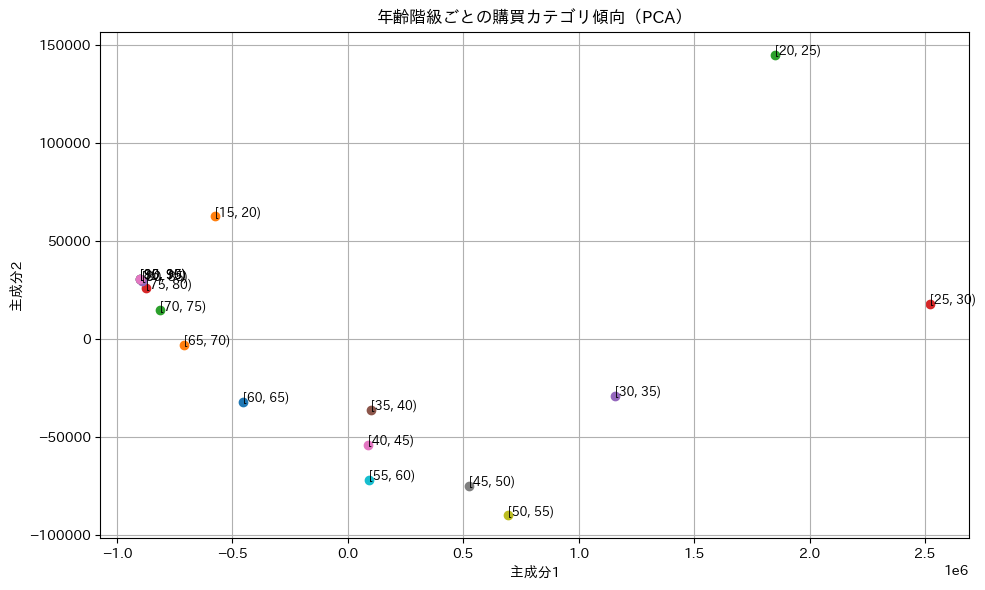

主成分1の寄与率: 99.61%
主成分2の寄与率: 0.31%


In [56]:
from sklearn.decomposition import PCA
import japanize_matplotlib
import matplotlib.pyplot as plt

# 1. PCAの入力データ（カテゴリの購入数）
X = grouped.values  # 年齢層ごとのカテゴリ購入数（行：年齢層, 列：カテゴリ）

# 2. 主成分分析（2次元に圧縮）
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 3. 可視化
plt.figure(figsize=(10, 6))
for i, age_group in enumerate(grouped.index.astype(str)):
    plt.scatter(X_pca[i, 0], X_pca[i, 1], label=age_group)
    plt.text(X_pca[i, 0], X_pca[i, 1], age_group, fontsize=9)

plt.title("年齢階級ごとの購買カテゴリ傾向（PCA）")
plt.xlabel("主成分1")
plt.ylabel("主成分2")
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. 寄与率を確認（どのくらい情報を保てているか）
explained = pca.explained_variance_ratio_
print(f"主成分1の寄与率: {explained[0]:.2%}")
print(f"主成分2の寄与率: {explained[1]:.2%}")


In [ ]:
# ↑の画像は購買総量と年齢の関係性であるため，プロット位置が大きくずれている年齢に関しては購買の総量が大きいことを示す．

# 若者はPCA1方向に大きく離れている→購買総量が大きいため
# 高齢者層はPCA2方向に大きく離れている→購買総量が小さいため
# 中間層は

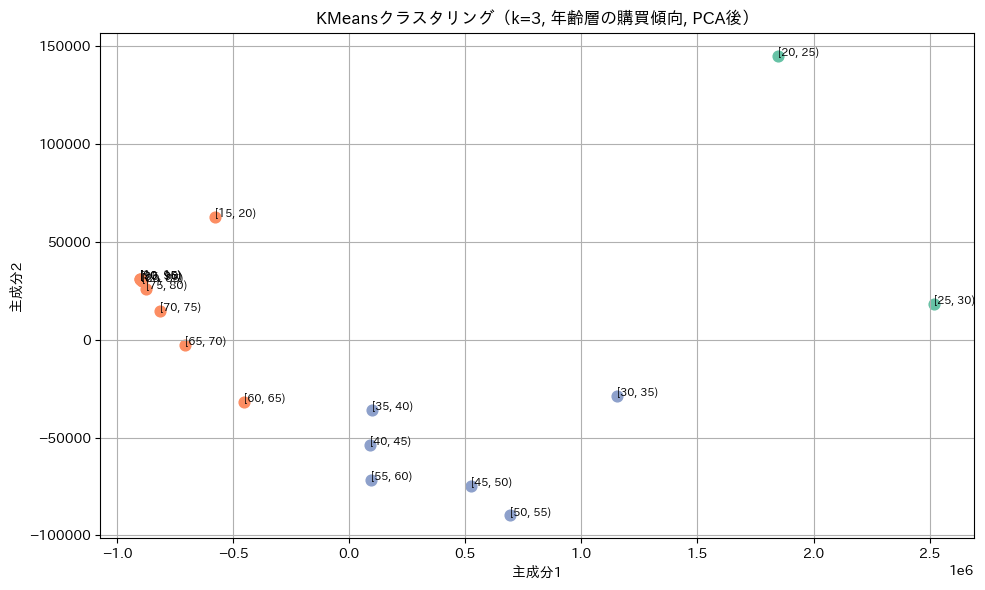

In [58]:
# 必要なライブラリ
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# すでに grouped が存在している前提で実行
X = grouped.values

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# KMeans（k=3）
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# プロット
plt.figure(figsize=(10, 6))
palette = sns.color_palette("Set2", 3)
for i, label in enumerate(grouped.index.astype(str)):
    plt.scatter(X_pca[i, 0], X_pca[i, 1], c=[palette[clusters[i]]], s=60)
    plt.text(X_pca[i, 0], X_pca[i, 1], label, fontsize=8)

plt.title("KMeansクラスタリング（k=3, 年齢層の購買傾向, PCA後）")
plt.xlabel("主成分1")
plt.ylabel("主成分2")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# 若者，中間層，高齢者層で，商品の購入数ではなく割合で算出して，年齢層毎に人気の商品を算出する

# 1. 年齢層を3区分に分類（任意で調整可能）
def categorize_age(age):
    if age < 30:
        return "若者"
    elif age < 60:
        return "中間層"
    else:
        return "高齢者"

merged["age_group3"] = merged["age"].apply(categorize_age)

# 2. 年齢層 × カテゴリで購入数を集計
age_cat_counts = merged.groupby(["age_group3", "product_group_name"]).size().unstack(fill_value=0)

# 3. 割合（パーセンテージ）に変換
age_cat_ratio = age_cat_counts.div(age_cat_counts.sum(axis=1), axis=0) * 100

# 4. 年齢層ごとに上位カテゴリを抽出
top_n = 5  # 上位5件にしたい場合
top_categories_per_group = {}

for group in age_cat_ratio.index:
    top = age_cat_ratio.loc[group].sort_values(ascending=False).head(top_n)
    top_categories_per_group[group] = top

# 5. 表示
for group, top_cats in top_categories_per_group.items():
    print(f"\n🔷 {group} の人気カテゴリ（割合ベース）")
    print(top_cats.round(2).astype(str) + " %")



🔷 中間層 の人気カテゴリ（割合ベース）
product_group_name
Garment Upper body    39.94 %
Garment Lower body    23.09 %
Garment Full body     11.59 %
Underwear              7.57 %
Swimwear               6.97 %
Name: 中間層, dtype: object

🔷 若者 の人気カテゴリ（割合ベース）
product_group_name
Garment Upper body     38.2 %
Garment Lower body    20.92 %
Garment Full body     10.59 %
Swimwear               9.96 %
Underwear              9.07 %
Name: 若者, dtype: object

🔷 高齢者 の人気カテゴリ（割合ベース）
product_group_name
Garment Upper body    46.15 %
Garment Lower body    23.34 %
Garment Full body     11.94 %
Underwear               4.6 %
Accessories            4.36 %
Name: 高齢者, dtype: object


In [70]:
# article_idをstrに統一（未実施なら）
merged["article_id"] = merged["article_id"].astype(str).str.zfill(10)

# 年齢層別の人気商品（article_id）を抽出
def get_top_articles_by_agegroup(age_group_label, top_n=10):
    # 対象データを抽出
    df = merged[merged["age_group3"] == age_group_label]

    # article_idごとにカウント
    article_counts = df["article_id"].value_counts().head(top_n)

    # article_idに対応する商品情報を articles_copy からマージ
    top_articles = pd.DataFrame({"article_id": article_counts.index, "count": article_counts.values})
    top_articles = top_articles.merge(articles_copy[["article_id", "product_type_name", "product_group_name"]], on="article_id", how="left")

    return top_articles

# 各年齢層の人気商品を取得
young_top = get_top_articles_by_agegroup("若者")
mid_top = get_top_articles_by_agegroup("中間層")
old_top = get_top_articles_by_agegroup("高齢者")

# 表示
print("🔷 若者の人気商品（article_id）")
display(young_top)

print("\n🔷 中間層の人気商品（article_id）")
display(mid_top)

print("\n🔷 高齢者の人気商品（article_id）")
display(old_top)


🔷 若者の人気商品（article_id）


,article_id,count,product_type_name,product_group_name
0,0706016001,30255,Trousers,Garment Lower body
1,0706016002,20266,Trousers,Garment Lower body
2,0759871002,18062,Vest top,Garment Upper body
3,0372860001,16689,Socks,Socks & Tights
4,0464297007,14558,Underwear bottom,Underwear
5,0156231001,14420,Underwear Tights,Socks & Tights
6,0610776002,13949,T-shirt,Garment Upper body
7,0448509014,12656,Trousers,Garment Lower body
8,0372860002,12322,Socks,Socks & Tights
9,0706016003,12121,Trousers,Garment Lower body



🔷 中間層の人気商品（article_id）


,article_id,count,product_type_name,product_group_name
0,0706016001,18903,Trousers,Garment Lower body
1,0610776002,14815,T-shirt,Garment Upper body
2,0372860001,14273,Socks,Socks & Tights
3,0706016002,13805,Trousers,Garment Lower body
4,0372860002,11511,Socks,Socks & Tights
5,0562245001,11431,Trousers,Garment Lower body
6,0399256001,11058,Trousers,Garment Lower body
7,0568601006,11006,Blazer,Garment Upper body
8,0608776002,10775,Socks,Socks & Tights
9,0610776001,10517,T-shirt,Garment Upper body



🔷 高齢者の人気商品（article_id）


,article_id,count,product_type_name,product_group_name
0,0579541001,1856,Cardigan,Garment Upper body
1,0399256005,1634,Trousers,Garment Lower body
2,0610776002,1435,T-shirt,Garment Upper body
3,0399256001,1433,Trousers,Garment Lower body
4,0610776001,1422,T-shirt,Garment Upper body
5,0678942001,1264,Top,Garment Upper body
6,0673677002,1244,Sweater,Garment Upper body
7,0706016001,1129,Trousers,Garment Lower body
8,0573716012,1129,Trousers,Garment Lower body
9,0572797002,1102,Vest top,Garment Upper body


In [73]:
# 前提：merged に t_dat（日付）, age_group3（年齢層）, article_id が含まれている
# articles_copy に article_id, product_type_name, product_group_name がある

# 1. 四半期ラベル列を作成
merged["t_dat"] = pd.to_datetime(merged["t_dat"])  # 念のため
merged = merged[(merged["t_dat"] >= "2018-10-01") & (merged["t_dat"] <= "2020-10-31")]

# 四半期ラベル作成
merged["quarter"] = pd.PeriodIndex(merged["t_dat"], freq="Q").astype(str)

# article_id を str に（ゼロ埋め10桁）
merged["article_id"] = merged["article_id"].astype(str).str.zfill(10)
articles_copy["article_id"] = articles_copy["article_id"].astype(str).str.zfill(10)

# 2. 四半期 × 年齢層ごとに article_id の出現数をカウント
grouped = (
    merged.groupby(["quarter", "age_group3", "article_id"])
    .size()
    .reset_index(name="count")
)

# 3. 各四半期 × 年齢層で人気上位10件を抽出
top_articles = (
    grouped.sort_values(["quarter", "age_group3", "count"], ascending=[True, True, False])
    .groupby(["quarter", "age_group3"])
    .head(10)
)

# 4. 商品情報をマージ
top_articles = top_articles.merge(
    articles_copy[["article_id", "product_type_name", "product_group_name"]],
    on="article_id",
    how="left"
)

# 5. 出力（例：四半期 × 年齢層ごとの上位商品を表示）
for (quarter, age_group), group in top_articles.groupby(["quarter", "age_group3"]):
    print(f"\n🔹 {quarter} - {age_group} の人気商品 TOP10")
    display(group[["article_id", "count", "product_type_name", "product_group_name"]].reset_index(drop=True))




🔹 2018Q4 - 中間層 の人気商品 TOP10


,article_id,count,product_type_name,product_group_name
0,0565379001,3416,Vest top,Garment Upper body
1,0562245001,3226,Trousers,Garment Lower body
2,0399223001,2644,Trousers,Garment Lower body
3,0179123001,2591,Leggings/Tights,Garment Lower body
4,0355072001,2365,Vest top,Garment Upper body
5,0608776002,2360,Socks,Socks & Tights
6,0484398001,2309,Leggings/Tights,Garment Lower body
7,0507910001,2260,Shirt,Garment Upper body
8,0108775015,2223,Vest top,Garment Upper body
9,0539723001,2220,Trousers,Garment Lower body



🔹 2018Q4 - 若者 の人気商品 TOP10


,article_id,count,product_type_name,product_group_name
0,0399223001,3455,Trousers,Garment Lower body
1,0539723001,3289,Trousers,Garment Lower body
2,0539723005,3037,Trousers,Garment Lower body
3,0156231001,2679,Underwear Tights,Socks & Tights
4,0484398001,2284,Leggings/Tights,Garment Lower body
5,0562245001,2129,Trousers,Garment Lower body
6,0108775015,2046,Vest top,Garment Upper body
7,0565379001,1978,Vest top,Garment Upper body
8,0111593001,1947,Underwear Tights,Socks & Tights
9,0663679001,1883,Dress,Garment Full body



🔹 2018Q4 - 高齢者 の人気商品 TOP10


...

,article_id,count,product_type_name,product_group_name
0,0751471001,2715,Trousers,Garment Lower body
1,0706016001,2034,Trousers,Garment Lower body
2,0610776002,1964,T-shirt,Garment Upper body
3,0783346001,1857,Trousers,Garment Lower body
4,0730683050,1845,Unknown,Unknown
5,0372860002,1790,Socks,Socks & Tights
6,0768912001,1767,Leggings/Tights,Garment Lower body
7,0841383002,1642,Vest top,Garment Upper body
8,0751471043,1625,Trousers,Garment Lower body
9,0678942001,1475,Top,Garment Upper body



🔹 2020Q3 - 若者 の人気商品 TOP10


,article_id,count,product_type_name,product_group_name
0,0706016001,3393,Trousers,Garment Lower body
1,0448509014,2711,Trousers,Garment Lower body
2,0751471001,2661,Trousers,Garment Lower body
3,0372860002,2372,Socks,Socks & Tights
4,0918292001,2245,Leggings/Tights,Garment Lower body
5,0760084003,2201,Trousers,Garment Lower body
6,0866731001,2187,Leggings/Tights,Garment Lower body
7,0806388002,2078,T-shirt,Garment Upper body
8,0915526001,2056,Sweater,Garment Upper body
9,0806388001,2055,T-shirt,Garment Upper body



🔹 2020Q3 - 高齢者 の人気商品 TOP10


,article_id,count,product_type_name,product_group_name
0,0896152002,484,T-shirt,Garment Upper body
1,0856840001,389,Dress,Garment Full body
2,0896169002,389,Cardigan,Garment Upper body
3,0751471043,310,Trousers,Garment Lower body
4,0783346001,299,Trousers,Garment Lower body
5,0751471001,297,Trousers,Garment Lower body
6,0896152001,281,T-shirt,Garment Upper body
7,0896152003,280,T-shirt,Garment Upper body
8,0579541001,246,Cardigan,Garment Upper body
9,0678942001,229,Top,Garment Upper body


In [65]:
merged.head()

,customer_id,article_id,t_dat,age,product_group_name,period,age_group3
0,000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318,0663713001,2018-09-20,24.0,Underwear,昔,若者
1,000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318,0541518023,2018-09-20,24.0,Underwear,昔,若者
2,00007d2de826758b65a93dd24ce629ed66842531df6699338c5570910a014cc2,0505221004,2018-09-20,32.0,Garment Upper body,昔,中間層
3,00007d2de826758b65a93dd24ce629ed66842531df6699338c5570910a014cc2,0685687003,2018-09-20,32.0,Garment Upper body,昔,中間層
4,00007d2de826758b65a93dd24ce629ed66842531df6699338c5570910a014cc2,0685687004,2018-09-20,32.0,Garment Upper body,昔,中間層


In [69]:
print(merged["period"].unique())

['昔' '直近']


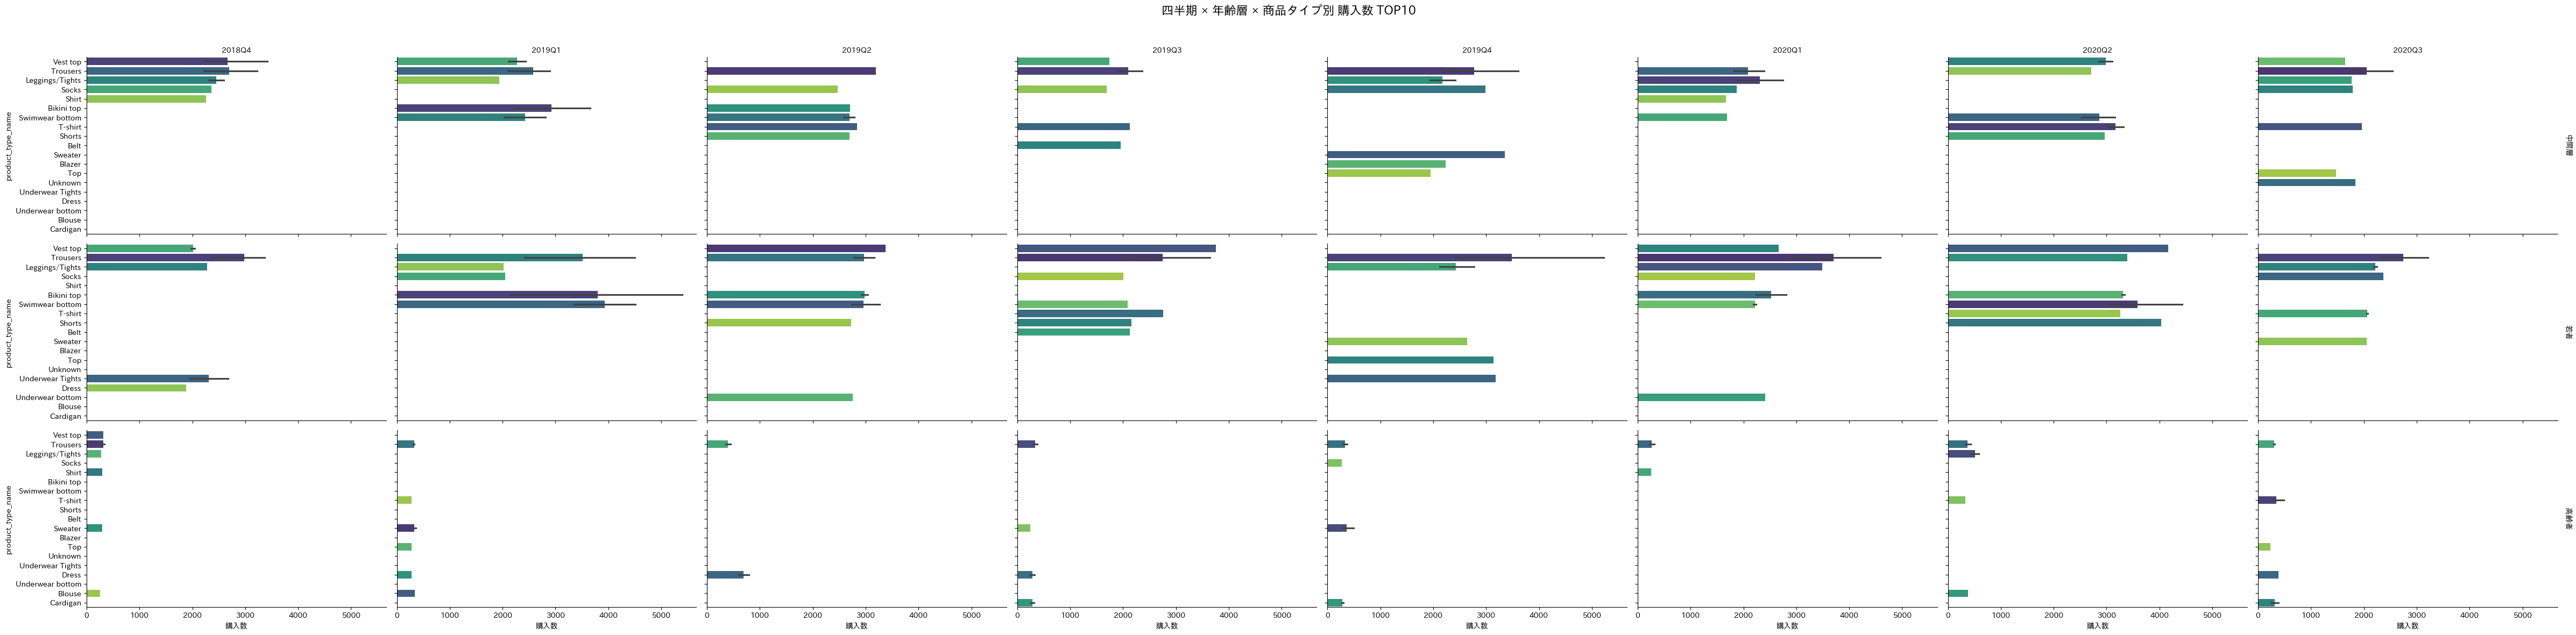

<Figure size 2000x1500 with 0 Axes>

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# 可視化対象を選ぶ（例：product_type_name または product_group_name）
target_col = "product_type_name"  # or "product_group_name"

# 全体のグリッド数を決定
n_quarters = top_articles["quarter"].nunique()
n_age_groups = top_articles["age_group3"].nunique()

# グラフの作成
g = sns.FacetGrid(top_articles, 
                  col="quarter", 
                  row="age_group3", 
                  margin_titles=True,
                  height=4,
                  aspect=1.5)

# 棒グラフの描画
g.map_dataframe(
    sns.barplot,
    y=target_col,
    x="count",
    order=None,
    palette="viridis"
)

# タイトルや調整
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.set_axis_labels("購入数", target_col)
plt.subplots_adjust(top=0.9)
g.fig.suptitle("四半期 × 年齢層 × 商品タイプ別 購入数 TOP10", fontsize=16)
plt.figure(figsize=(20, 15))
plt.tight_layout()
plt.show()


# 推薦が12個未満の時に埋めるアルゴリズム

In [ ]:
# --- 0. 準備 ---
# 12個未満の時に使う fallback 用の人気記事ランキング
# top_items_dict, popular_articles は既に作成済みとする

# 1. 顧客ごとの予測 article_id を 12個に補完する関数
def recommend_12_articles_with_context(article_list, quarter, age_group):
    article_list = [str(a).zfill(10) for a in article_list]  # ゼロ埋め
    if len(article_list) >= 12:
        return article_list[:12]
    else:
        needed = 12 - len(article_list)
        key = (quarter, age_group)
        if key in top_items_dict:
            fill_items = [a for a in top_items_dict[key] if a not in article_list]
        else:
            fill_items = [a for a in popular_articles if a not in article_list]
        return article_list + fill_items[:needed]

# 2. unknown_customers に quarter 列を追加（t_dat列が必要）
unknown_customers["quarter"] = pd.PeriodIndex(unknown_customers["t_dat"], freq="Q").astype(str)

# 3. top12 に予測結果（学習済みモデルから取得）を格納済みと仮定して整形
# top12: customer_id, article_id があり、12個未満も含まれる
# unknown_customers: customer_id, age_group3, t_dat（→ quarter）

# 4. 顧客ごとに 12個に補完した article_id を生成
merged_pred = top12.merge(unknown_customers[["customer_id", "quarter", "age_group3"]], on="customer_id", how="left")

submission_pred = (
    merged_pred.groupby("customer_id")
    .apply(lambda df: ' '.join(
        recommend_12_articles_with_context(df['article_id'].tolist(), df['quarter'].iloc[0], df['age_group3'].iloc[0])
    ))
    .reset_index(name='prediction')
)

# 5. sample_submission に結合
submission = sample_submission[['customer_id']].merge(submission_pred, on='customer_id', how='left')

# 欠損顧客への fallback 推薦
fallback_12 = ' '.join(popular_articles[:12])
submission['prediction'] = submission['prediction'].fillna(fallback_12)

# 6. 保存
submission.to_csv("submission.csv", index=False)
print("✅ 年齢層 × 時系列ベースの補完付き submission.csv を保存しました")
